In [70]:
import qil_helpers.Ben.General as Ben
import matplotlib.pyplot as plt
import numpy as np
import qil_SpinHamiltonian.spin_hamiltonian as spin
import yaml
import matplotlib.colors as clr
import plotly.graph_objects as go
import scipy as sp


In [71]:
G=np.array([124.1,-20.0,-1.19,-20.0,-106.7,0.80,-1.19,0.80,-110.1])
sort=[0,3,4,3,1,5,4,5,2]
S=G[sort]
print(len(G),len(G[sort]))
print(G[sort])

print("np.matrix([[%s,%s,%s],[%s,%s,%s],[%s,%s,%s]])"%tuple(S))


9 9
[ 124.1   -20.   -106.7   -20.    -20.      0.8  -106.7     0.8    -1.19]
np.matrix([[124.1,-20.0,-106.7],[-20.0,-20.0,0.8],[-106.7,0.8,-1.19]])


{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Rotation': {'rot': 'ZXZ'}, 'E_Zeeman': {'g': 'np.diag([2.16,-0.1,14.7])', 'g_rot': 'np.array([205.2,55.3,30])*np.pi/180'}, 'N_Zeeman': {'mu': '-0.56'}, 'Hyperfine': {'A': 'np.diag([191.1,-36,1544])*1e6*h', 'A_rot': 'np.array([202,51.8,-6])*np.pi/180'}, 'Quadrupole': {'Q': 'np.diag([9.6,18.3,-27.9])*1e6*h', 'Q_rot': 'np.array([147,50,316])*np.pi/180'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}
[[9.06307787e-01]
 [4.22618262e-01]
 [1.66533454e-16]]


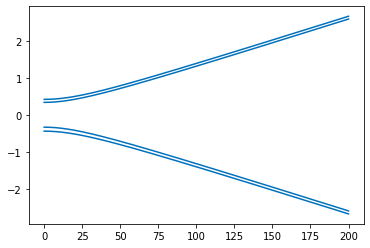

[[ 2.01714261e-25 -1.80120509e-25 -1.78968433e-25]
 [-1.80120509e-25  5.46891460e-25  4.75792078e-25]
 [-1.78968433e-25  4.75792078e-25  3.77686976e-25]]


In [ ]:
path="../ion_params/"
gnd="Yb_CAWO.yml"
#gnd="Er"
gnd="Er_YSO_site1_ground_wang.yml"
#gnd="Er_YSO_site1_ground_chen.yml"
#gnd="Er_YSO_site2_ground_wang.yml"

#gnd="Yb_CAWO_D2_1.yml"

spinG=spin.hamilFromYAML(path+gnd,IOveride=1/2)
uvec=spin.sphereUnit((np.pi/2,25*np.pi/180))
print(uvec)
#uvec=np.array([0,0,1]).T
#uvec=uvec/np.linalg.norm(uvec)

pts=1000
Bz=np.linspace(-000E-3,200E-3,pts)

Bzv=np.outer(uvec,Bz)
FG,VG=spinG.getEigFreq(Bzv)
plt.plot(Bz*1E3,FG,Ben.ROYALBLUE)
#plt.ylim([-3,3])

plt.show()


print(spinG.A)

In [73]:
dim=spinG.dim
a,b=spin.tilerepidx(dim)
X=a.reshape(dim,dim)
Y=b.reshape(dim,dim)
Z=np.arange(dim**2).reshape(dim,dim)
i,j=np.triu_indices(spinG.dim,k=1)
idx=np.where(np.logical_and(i==8,j==10))[0]
print(idx)
# #mask=np.tri(*Z.shape,k=1)

# #fig=go.Figure(data=go.Histogram2d(x=a,y=b,z=Z,texttemplate='%{z}',nbinsx=16,nbinsy=16))
# #fig=go.Figure(data=go.Heatmap(z=Z,texttemplate='%{z}'))
# #fig.show()
# mZ=np.ma.array(Z,mask=mask)
# plt.pcolor(mZ)


[]


In [74]:
thetas=np.linspace(0,2*np.pi,5*24)#np.linspace(0,2*np.pi,100)
phis=np.linspace(0,np.pi,1)#0#np.pi/2#*np.ones_like(thetas)
Bs=np.linspace(0,1,5*20)

thetas=np.linspace(0,2*np.pi,2*6)#np.linspace(0,2*np.pi,100)
phis=np.linspace(0,np.pi,1)#0#np.pi/2#*np.ones_like(thetas)
Bs=np.linspace(0,1,2*6)

# thetas=np.linspace(0,2*np.pi,240)#np.linspace(0,2*np.pi,100)
# phis=np.linspace(0,np.pi,1)#0#np.pi/2#*np.ones_like(thetas)
# Bs=np.linspace(10E-3,6,2*20)

#Bs=1
B,T,P=np.meshgrid(Bs,thetas,phis)
# x=r*np.outer(np.sin(thetas),np.cos(phis))
# y=r*np.outer(np.sin(thetas),np.sin(phis))
# z=r*np.outer(np.ones(np.size(phis)),np.cos(thetas))
x=(B*np.sin(T)*np.cos(P)).flatten()
y=(B*np.sin(T)*np.sin(P)).flatten()
z=(B*np.cos(T)).flatten()


#fig=go.Figure(data=go.Surface(x=x.reshape(100,100),y=y.reshape(100,100),z=z.reshape(100,100),showscale=False))
fig=go.Figure(data=go.Scatter3d(x=x,y=y,z=z))
fig.show()
vec=np.vstack([x,y,z])
Bu=vec/np.linalg.norm(vec,axis=0)

print(vec.shape)

vec=np.array(spinG.RE@vec)
n=vec.shape[1]//120#500
#fig=go.Figure(data=go.Scatter3d(x=x,y=y,z=z))
pre=go.Scatter3d(x=vec[0,:n],y=vec[1,:n],z=vec[2,:n])
np.random.shuffle(vec.T)
vec=vec
post=go.Scatter3d(x=vec[0,:n],y=vec[1,:n],z=vec[2,:n])
fig=go.Figure(data=[pre,post])
fig.show()


(3, 144)


C:\Users\neb16\AppData\Local\Temp/ipykernel_20048/1471340803.py:27: RuntimeWarning:

invalid value encountered in divide



In [75]:
%%script False
FG,VG=spinG.getEigFreq(vec)


gradG=spinG.gradient(VG)
curvG=spinG.curvature(VG,FG)
Sp=np.max(np.abs(np.linalg.eigvals(curvG)),axis=-1)



#Bu=Bzv/np.linalg.norm(Bzv,axis=0)
udT=np.einsum('kji,ik->jk',gradG,Bu).T

#plt.plot()
#fig=go.Figure(data=[go.Surface(x=x.reshape(100,100),y=z.reshape(100,100),z=FG[:,i].reshape(100,100),showscale=False) for i in range(FG.shape[1])])
fig=go.Figure(data=[go.Surface(x=x.reshape(B.shape[:-1]),y=z.reshape(B.shape[:-1]),z=udT[:,i].reshape(B.shape[:-1])+000*i,showscale=False) for i in range(FG.shape[1])])
fig.show()
fig=go.Figure(data=[go.Surface(x=x.reshape(B.shape[:-1]),y=z.reshape(B.shape[:-1]),z=Sp[:,i].reshape(B.shape[:-1]),showscale=False) for i in range(Sp.shape[1])])
fig.show()

Couldn't find program: 'False'


In [76]:




def takeBlock(A):
    i,a,n=A.shape
    k=n//a
    print(k)
    B=A.reshape(3,a,a,k)
    B=B[:,np.arange(a),np.arange(a)].reshape(3,n)
    return B

#subset=A[:,:,:k]
#subset=subset.reshape(3,10*120)
#i=np.arange(120)
#j=


In [ ]:
#%%script False
B=vec
i,j=np.triu_indices(spinG.dim,k=1)
#i,j=0,3
#i,j=8,10
pts=B.shape[1]


for k in range(10):
    print(k)
    FG,VG=spinG.getEigFreq(B)


    gradG=spinG.gradient(VG)
    curvG=spinG.curvature(VG,FG)

    S1=gradG[:,i,:]-gradG[:,j,:]#spin.eachElemFunc(gradG,gradG)
    S2=curvG[:,i,:,:]-curvG[:,j,:,:]#spin.eachElemFunc(curvG,curvG)
    eps=1E-12
    try:
        C=np.linalg.inv(S2+eps*np.eye(3))
    except:
        print("Singular matrix stopping!!!!")
        break
    dx=np.einsum('...ij,...j->...i',C,S1)
    #dx=10/(k+1)*S1

    #B=B-dx[:,93,:].T
    B=B-takeBlock(dx.T)
    #x=B[0,:]

print("Final Iterations: %s"%k)
fig=go.Figure(data=go.Scatter3d(x=B[0,:],y=B[1,:],z=B[2,:]))
fig.show()



0
24
1
24
2
24
3
24
4
24
5
24
6
24
7
24


8
24
9
24
Final Iterations: 9


In [ ]:
Test=S1
test2=takeBlock(S1.T)
#``

Tidx=np.repeat(np.arange(6),24)
Tidx=np.arange(Tidx.shape[0])//24

Tslice=Test[np.arange(Tidx.shape[0]),Tidx,...]

#print(==)
#print(test2.T[1,:],Test[1,0,...])
print(np.allclose(test2.T[np.arange(Tidx.shape[0]),:],Tslice))
# print(Test[2,...])

# #print(Test[6...])

# print('\n')
# print(test2.T)

24
True
[[-2.41598012e-03  3.20684122e-03  1.44423457e-03]
 [-7.21270883e+01  1.52860568e+02  1.17157217e+02]
 [-7.21295043e+01  1.52863775e+02  1.17158661e+02]
 [-7.21246723e+01  1.52857362e+02  1.17155772e+02]
 [-7.21270883e+01  1.52860568e+02  1.17157217e+02]
 [-2.41598019e-03  3.20684121e-03  1.44423446e-03]]


[[-1.98918355e-03 -7.63793955e-04  3.69680560e-03]
 [-1.90958360e-13  4.34319247e-13  3.23296945e-13]
 [-2.41598012e-03  3.20684122e-03  1.44423457e-03]
 [-1.90958360e-13  4.34319247e-13  3.23296945e-13]
 [-1.41171312e-03  2.87439208e-03  2.22718665e-03]
 [-8.05535895e-04  3.90001584e-03  1.53218550e-03]
 [ 6.99683346e-02 -1.39634651e-01 -1.08052962e-01]
 [ 1.78132949e-03 -3.71510032e-03 -2.82812920e-03]
 [ 1.14762853e-03 -3.07737876e-03 -2.72383787e-03]
 [ 8.95921387e-03 -1.69996378e-02 -1.29932522e-02]
 [ 5.47157253e-02 -1.11125363e-01 -8.73920629e-02]
 [-7.20044780e-03  1.84603952e-02  1.34162705e-02]
 [ 1.69296385e-03 -3.39868938e-03 -2.59788785e-03]
 [-3.48692627e-03 -1

24
24


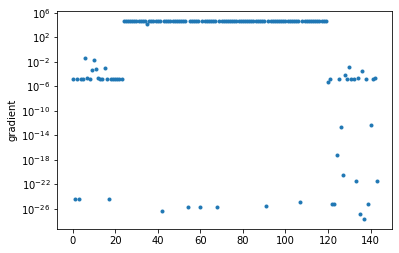

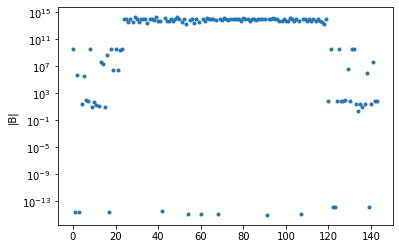

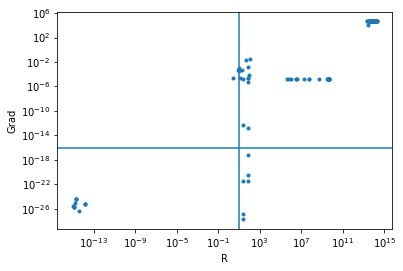

In [79]:

dfdB=np.einsum('ij,ij->i',takeBlock(S1.T).T,takeBlock(S1.T).T)
plt.plot(dfdB,'.')
plt.ylabel('gradient')
plt.yscale('log')
plt.show()

R=np.linalg.norm(B,axis=0)
theta=np.acos(B[2,:]/R)
phi=np.sign(B[1,:])*np.acos(B[0,:]/np.sqrt(np.square(B[0,:])+np.square(B[1,:])))

plt.plot(R,'.')
plt.ylabel('|B|')

plt.yscale('log')
plt.show()

Rt=1E1
Gt=1E-16

mask=np.logical_and(R<Rt,dfdB<Gt)
idx=np.where(mask)[0]


plt.plot(R,dfdB,'.')
plt.axvline(Rt)
plt.axhline(Gt)


plt.xscale('log')
plt.yscale('log')
plt.xlabel("R")
plt.ylabel("Grad")
#plt.xlim([None,1E1])
plt.show()


off=8
RT=spinG.RE
CE=RT@np.eye(3)#@R
axis=['x','y','z']
coords=[go.Scatter3d( x = [-off*CE[0,i],off*CE[0,i]],
                       y = [-off*CE[1,i],off*CE[1,i]],
                       z = [-off*CE[2,i],off*CE[2,i]],
                       line = dict( color = "rgb(0,0,0)",
                                    width = 6),
                        text=l,
                        mode='lines'
                     ) for i,l in enumerate(axis)]


fig=go.Figure(data=[go.Scatter3d(x=B[0,idx],y=B[1,idx],z=B[2,idx],mode='markers',
marker=dict(
        size=5,
        opacity=0.5
    )

),*coords])
fig.update_layout(
    scene=dict(
        annotations=[dict(
            x=off*CE[0,i],
            y=off*CE[1,i],
            z=off*CE[2,i],
            text=l,
            showarrow=False
        ) for i,l in enumerate(axis)]
    ))

fig.show()
#dfddB=np.linalg.det(S2[idx,:,:,:])#np.max(np.abs(np.linalg.eigvals(S2[idx,:,:,:])),axis=-1)



In [80]:
raise ValueError

ValueError: 

In [ ]:
Blist=np.unique(np.round(B[:,idx],3),axis=1)
#sidx=np.argsort(R[idx])
print(Blist.T)

#np.save('./saved/wang.npy',Blist,allow_pickle=True)
#np.save('./saved/chen.npy',Blist,allow_pickle=True)
np.save('./saved/site_2_2.npy',B,allow_pickle=True)

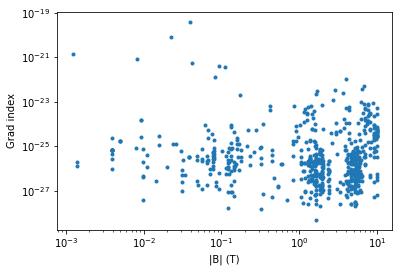

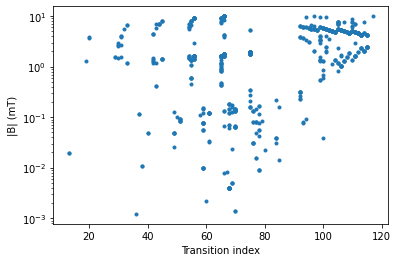

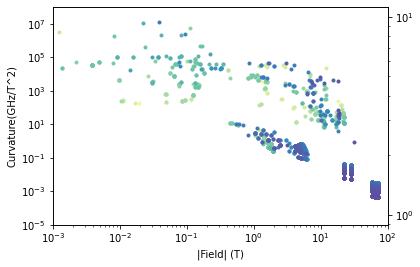

66: 5<->7


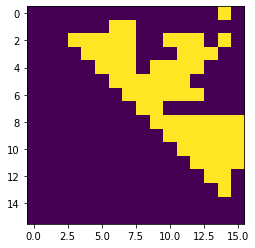

In [ ]:
n,a,_=S1.shape
##B.shape
k=n//a
Br=B.reshape(3,a,k)
S1r=S1.reshape(k,a,a,3)

plt.plot(R[idx],dfdB[idx],'.')
plt.ylabel("Grad index")
plt.xlabel("|B| (T)")
plt.yscale('log')
plt.xscale('log')
plt.show()


plt.plot(idx//k,R[idx],'.')
plt.xlabel("Transition index")
plt.ylabel("|B| (mT)")
plt.yscale('log')
plt.show()


#Bsr=np.einsum('ijk,ijk->jk',Br,Br)
#cm=plt.cm.BuPu(np.linspace(0.5,1,a))
cm=plt.cm.Spectral(np.linspace(0.5,1,a))
cmG=plt.cm.OrRd(np.linspace(0.5,1,a))

#Ben.goodColourmap(plt.cm.BuPu,a)
i,j=np.triu_indices(spinG.dim,k=1)
#pl
plt.plot([],[])
ax=plt.gca()
ax2=ax.twinx()
    
for l in range(a):
    FGs,VGs=spinG.getEigFreq(Br[:,l,:])


    gradGs=spinG.gradient(VGs)
    curvGs=spinG.curvature(VGs,FGs)

    S1s=gradGs[:,i[l],:]-gradGs[:,j[l],:]#spin.eachElemFunc(gradG,gradG)
    S2s=curvGs[:,i[l],:]-curvGs[:,j[l],:]#spin.eachElemFunc(curvG,curvG)
    S2val=np.max(np.abs(np.linalg.eigvals(S2s)),axis=-1)
    S1val=np.einsum('ij,ij->i',S1s,S1s)
#    plt.plot(l*np.ones(S1s.shape[0]),S1val,'C%s.'%l)
    #plt.plot(S1val,S2val,'.',color=cm[l])
    Bval=np.linalg.norm(Br[:,l,:],axis=0)
    #plt.plot(S2val,Bval,'.')
    ax.plot(Bval,S2val,'.',color=cm[l])

    #ax2.plot(Bval,S1val,'x',color=cmG[l])
ax.set_ylabel("Curvature(GHz/T^2)")
ax.set_xlabel("|Field| (T)")
#plt.xlabel("Gradient(GHz/mT)")
#plt.xlim([1E-2,1E8])
#plt.ylim([1E1,1E4])

#plt.xlim([1E-3,1E8])
#plt.ylim([1E-4,1E1])
ax.set_xscale('log')
ax.set_yscale('log')
ax2.set_yscale('log')
ax.set_ylim([1E-5,1E8])
ax.set_xlim([1E-3,1E2])
plt.show()

U,C=np.unique(idx//k,return_counts=True)
#plt.plot(U,C)
#plt.show()
tMax=U[np.argmax(C)]

print("%s: %s<->%s"%(tMax,i[tMax],j[tMax]))

Matdist=np.zeros((spinG.dim,spinG.dim))
Matdist[i[U],j[U]]=np.ones_like(C)
plt.imshow(Matdist)
plt.show()

#plt.plot(idx,idx//k)
#plt.show()
# MatR=R#np.zeros((spinG.dim,spinG.dim))
# MatR[~mask]=np.nan
# MatR=MatR.reshape(-1,spinG.dim,spinG.dim)
# mnMatR=np.nanmean(MatR,axis=0)
# #MatR[i[U],j[U]]=np.mean(R[U])
# #MatR=R[idx]

# plt.imshow(mnMatR)

A: 0.75±0.01, B: 2.11±0.04, C: -0.89±0.06


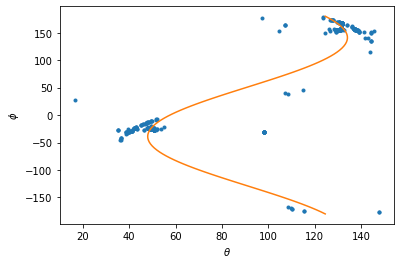

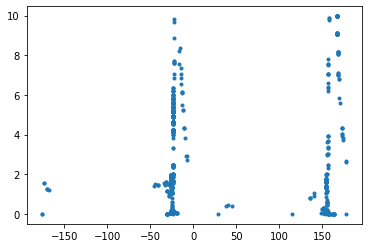

In [ ]:
plt.plot(theta[idx]*180/np.pi,phi[idx]*180/np.pi,'.')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\phi$')
phit=np.linspace(-np.pi,np.pi,100)#+5*np.pi/180

func=lambda x,A,B,C: A*(np.sin(x+C)+B)

p,r=sp.optimize.curve_fit(func,phi[idx],theta[idx])

Ben.fitInfo(func,p,r)

thett=func(phit,*p)#(50*np.sin(phit-5*np.pi/180)+90)*np.pi/180

plt.plot(thett*180/np.pi,phit*180/np.pi)
plt.show()

plt.plot(phi[idx]*180/np.pi,R[idx],'.')



In [ ]:
off=1
RT=spinG.RE
CE=RT@np.eye(3)#@R
axis=['x','y','z']
coords=[go.Scatter3d( x = [-off*CE[0,i],off*CE[0,i]],
                       y = [-off*CE[1,i],off*CE[1,i]],
                       z = [-off*CE[2,i],off*CE[2,i]],
                       line = dict( color = "rgb(0,0,0)",
                                    width = 6),
                        text=l,
                        mode='lines'
                     ) for i,l in enumerate(axis)]
RA=spinG.RH
CA=RA@np.eye(3)#@R
axis=['x','y','z']
coordsA=[go.Scatter3d( x = [-off*CA[0,i],off*CA[0,i]],
                       y = [-off*CA[1,i],off*CA[1,i]],
                       z = [-off*CA[2,i],off*CA[2,i]],
                       line = dict( color = "rgb(0,0,0)",
                                    width = 6,dash='dash'),
                        text=l,
                        mode='lines',
                        
                     ) for i,l in enumerate(axis)]

fig=go.Figure(data=[go.Scatter3d(x=1*np.sin(theta[idx])*np.cos(phi[idx]),y=1*np.sin(theta[idx])*np.sin(phi[idx]),z=np.cos(theta[idx]),mode='markers',
marker=dict(
        size=2,
        opacity=0.5
    )

),*coords,*coordsA])
fig.show()


xt=1*np.sin(thett)*np.cos(phit)
yt=1*np.sin(thett)*np.sin(phit)
zt=np.cos(thett)
fig=go.Figure(data=[go.Scatter3d(x=xt,y=yt,z=zt,mode='markers',
marker=dict(
        size=1,
        opacity=0.5
    )

)])
fig.show()



In [ ]:
fig=go.Figure(data=[go.Scatter3d(x=x[idx],y=y[idx],z=z[idx],mode='markers',
marker=dict(
        size=2,
        opacity=0.5
    )

)])#
fig.show()



In [ ]:
raise ValueError("Stop You've violated the law!!!")

ValueError: Stop You've violated the law!!!

In [ ]:
i,j=0,3
def gradFunc(B):
    B=B.reshape(3,-1)
    FG,VG=spinG.getEigFreq(B)
    grad=spinG.gradient(VG)
    #print(grad.shape)
    S1=grad[...,i,:]-grad[...,j,:]
    #print(S1.shape)
    if len(S1.shape)>1:
        return np.einsum('ij,ij->i',S1,S1)
    else:
        return np.dot(S1,S1)
G=gradFunc(vec.flatten())
fig=go.Figure(data=go.Scatter3d(x=x,y=y,z=z,mode='markers',
    marker=dict(
        size=5,
        color=G,                # set color to an array/list of desired values
        colorscale='Viridis',   # choose a colorscale
        opacity=0.2
    )))
fig.show()



In [ ]:
vals=[]
for k in range(vec.shape[1]//4):
    res=sp.optimize.minimize(gradFunc,vec[:,k],method='BFGS')
    vals.append(res.x)
    #print(res)

vals=np.array(vals)


KeyboardInterrupt: 

In [ ]:

fig=go.Figure(data=go.Scatter3d(x=vals[0,:],y=vals[1,:],z=vals[2,:],mode='markers',
    marker=dict(
        size=5,
        color=G,                # set color to an array/list of desired values
        colorscale='Viridis',   # choose a colorscale
        opacity=1
    )))
fig.show()



In [ ]:
%%script False
#res=sp.optimize.leas(gradFunc,np.array([1,1,1]),method='BFGS')
rs=sp.optimize.least_squares(gradFunc,vec.flatten())
print(rs)
#

Couldn't find program: 'False'


In [ ]:
#print(res)
#print(rs)